In [1]:
import sys

custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
if custom_module_path not in sys.path:
    sys.path.append(custom_module_path)

import instruments_jax as inst
import copy
import numpy as np
import json


# Step 1.a): Reading in csv - extracting single diffs and sums and configurations

In [2]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"
wavelength_string = 670
obs_mode = "MBI"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)
print("Interleaved Values")
print("Length: ", len(interleaved_values))
print(interleaved_values)
print("Interleaved Stds")
print("Length: ", len(interleaved_stds))
print(interleaved_stds[0 : 10])
print("Configuration List")
print("Length: ", len(configuration_list))
print(configuration_list)

print(interleaved_stds[0])

Interleaved Values
Length:  320
[  4891.    12895.5   -8596.    13342.5    1190.5   12976.    -5411.5
  13045.    -6623.5   13368.5    2486.    12814.   -12740.5   13944.
   9496.5   12967.5  -13235.    13903.    11358.    13094.5   -8040.5
  13293.     7342.5   13117.5    -674.    12906.      334.5   13393.
   3112.    12875.5   -3963.    13650.     4450.    13125.5   -6885.5
  13580.     6726.5   12994.5   -9906.    13737.5    2201.    13172.5
  -6372.5   13278.    -6036.    13547.5    1799.5   12976.5  -12123.5
  14053.     8802.    12981.   -12333.5   13903.    10326.    13109.5
  -7081.    13226.     6317.    13089.     -227.    12805.      -70.5
  13321.5    1057.    13329.    -2102.5   13579.     8027.5   13096.5
  -9776.    13947.5    9101.    13241.   -12201.    13999.     3880.5
  13327.5   -8014.5   13505.5   -4793.5   13695.5     477.5   13135.5
 -10556.    14132.     7209.5   12967.   -10266.    13911.     8276.
  12972.    -4663.    13153.     3708.25  13091.    -2852.   

In [3]:
%%timeit

import copy


copy.deepcopy(interleaved_values)

6.59 µs ± 2.13 µs per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


# Step 1.b) - Make plot of existing values as double diffs and sums

# Step 2: Creating a system Mueller matrix object

In [4]:
# Loading in previous fit from vampires_calibration
from pathlib import Path

fallback_filename = "/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/675-50_no_IMR_offset_iterate_on_any_improvement_ideal_start_table_phi_with_dichroic_best_fit_old_fit_values_EM_gain_1.txt"
saved_fit_filename = f"/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/{wavelength_string}_no_IMR_offset_fixed_EM_gain_1_no_retardance_constraints_iterate_on_any_improvement_from_broadband_ideal_start_table_phi_with_dichroic_best_fit_old_fit_values.txt"

if Path(saved_fit_filename).exists():
    filename = saved_fit_filename
    print("Resuming from saved MBI scipy.minimize fit: " + filename)
else:
    filename = fallback_filename
    print("Starting from closest broadband filter fit: " + filename)
with open(filename, "r") as f:
    past_fit = json.load(f)
past_fit.pop("wollaston", None)
past_fit.setdefault("image_rotator", {})
past_fit["image_rotator"].pop("delta_theta", None)

print(past_fit)

theta_pol = past_fit["lp"]["theta"]
delta_HWP = past_fit["hwp"]["phi"] 
offset_HWP = past_fit["hwp"]["delta_theta"]
delta_derot = past_fit["image_rotator"]["phi"] 
offset_derot = 0
delta_opts = past_fit["optics"]["phi"]
epsilon_opts = past_fit["optics"]["epsilon"]
rot_opts = past_fit["optics"]["theta"]
delta_FLC = past_fit["flc"]["phi"] 
rot_FLC = past_fit["flc"]["delta_theta"]
dichroic_phi = past_fit.get("dichroic", {}).get("phi", 0)
dichroic_epsilon = past_fit.get("dichroic", {}).get("epsilon", 0)
dichroic_theta = past_fit.get("dichroic", {}).get("theta", 0)
em_gain = 1.0  # Fixed ideal EM gain

# Based on values in Six_And_Eleven_Parameter_Model_Best_MCMC_and_Scipy_Fits Google Sheets - having zeros for angles that're too large
# theta_pol = 0
# delta_HWP = 0.451  # Add your actual delta_HWP value
# offset_HWP = -2.642  # Add your actual offset_HWP value
# delta_derot = 0.32  # Add your actual delta_derot value
# offset_derot = 0  # Add your actual offset_derot value
# delta_opts = 0  # Add your actual delta_opts value
# epsilon_opts = 0  # Add your actual epsilon_opts value
# rot_opts = 0  # Add your actual rot_opts value
# delta_FLC = 0.5  # Add your actual delta_FLC value
# rot_FLC = 0  # Add your actual rot_FLC value
# em_gain = 1.2  # Add your actual em_gain value

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary
system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": dichroic_phi, "epsilon": dichroic_epsilon, "theta": dichroic_theta},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_FLC, "theta": 0, "delta_theta": rot_FLC},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": delta_opts, "epsilon": epsilon_opts, "theta": rot_opts},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_derot, "theta": 0, "delta_theta": 0},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_HWP, "theta": 0, "delta_theta": offset_HWP},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        }
    }
}

Starting from closest broadband filter fit: /home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/675-50_no_IMR_offset_iterate_on_any_improvement_ideal_start_table_phi_with_dichroic_best_fit_old_fit_values_EM_gain_1.txt
{'dichroic': {'phi': 0.1051366940108763, 'epsilon': 0.4542525923562888, 'theta': 39.55625778395081}, 'flc': {'phi': 3.0783860479340572, 'delta_theta': 4.999999999473679}, 'optics': {'phi': -1.5205319358901306, 'epsilon': 0.004874865477118963, 'theta': 18.571141761444864}, 'image_rotator': {'phi': 2.109582825093769}, 'hwp': {'phi': 2.9018593071482908, 'delta_theta': 2.4547788597893865}, 'lp': {'theta': 4.999999977406556}}


In [5]:
# Converting system dictionary into system Mueller Matrix object

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())

[[0.42101806 0.41462185 0.07310902 0.        ]
 [0.42101806 0.41462185 0.07310902 0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]]


# Step 4: Creating a dictionary of p0 starting guesses

{'dichroic': {'phi': 0.1051366940108763, 'epsilon': 0.4542525923562888, 'theta': 39.55625778395081}, 'flc': {'phi': 3.0783860479340572, 'delta_theta': 4.999999999473679}, 'optics': {'phi': -1.5205319358901306, 'epsilon': 0.004874865477118963, 'theta': 18.571141761444864}, 'image_rotator': {'phi': 2.109582825093769}, 'hwp': {'phi': 2.9018593071482908, 'delta_theta': 2.4547788597893865}, 'lp': {'theta': 4.999999977406556}}
logl value: 11946.060618054604


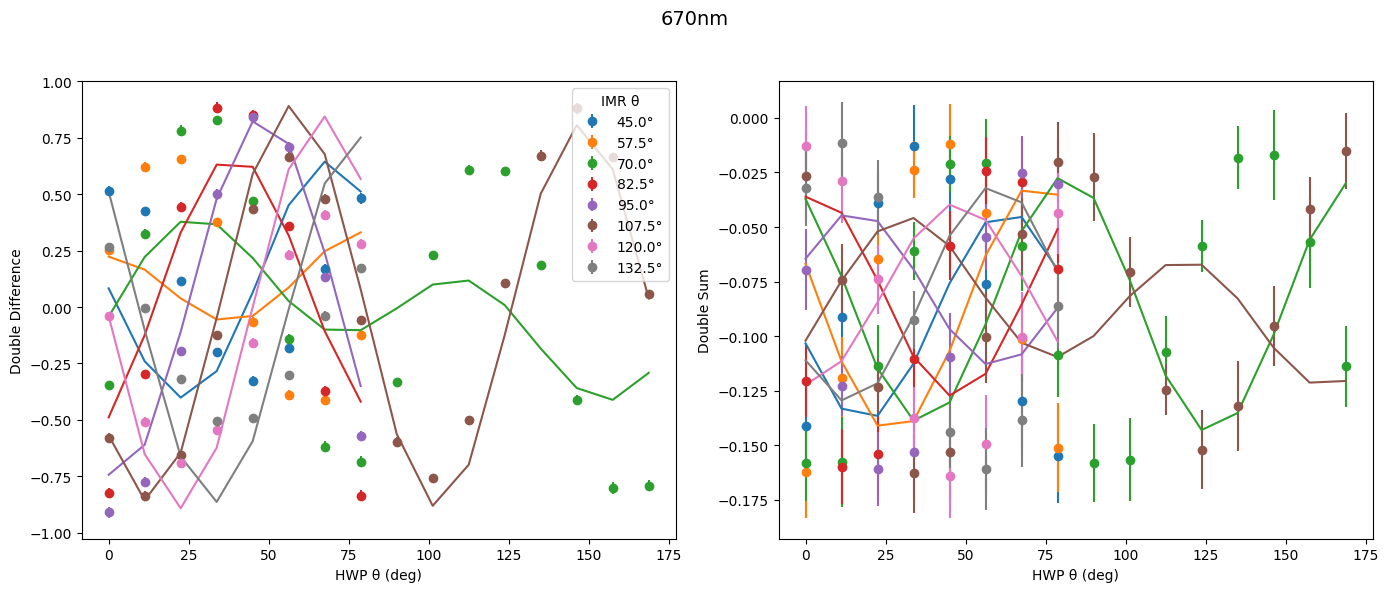

In [6]:
# Fitting all non-EM-gain parameters
p0 = copy.deepcopy(past_fit)
p0.pop("wollaston", None)

print(p0)

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting intial plot
updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)

# Step 5: Running minimize_system_Mueller_matrix iteratively

Before p0: {'dichroic': {'phi': 0.1051366940108763, 'epsilon': 0.4542525923562888, 'theta': 39.55625778395081}, 'flc': {'phi': 3.0783860479340572, 'delta_theta': 4.999999999473679}, 'optics': {'phi': -1.5205319358901306, 'epsilon': 0.004874865477118963, 'theta': 18.571141761444864}, 'image_rotator': {'phi': 2.109582825093769}, 'hwp': {'phi': 2.9018593071482908, 'delta_theta': 2.4547788597893865}, 'lp': {'theta': 4.999999977406556}}
Iteration #: 1
logl_value: 25.130466841483518
Best Fit Parameters: [-1.55597972e-02  2.82939390e-01  3.60471605e+01  3.03057546e+00
  5.00000000e+00 -2.34183395e+00  3.20485546e-03  4.66247896e+00
  2.00259461e+00  2.88610791e+00  9.55317098e-01  4.78608186e+00]
After p0: {'dichroic': {'phi': -0.015559797190428434, 'epsilon': 0.282939390239206, 'theta': 36.04716048465626}, 'flc': {'phi': 3.0305754584080775, 'delta_theta': 5.0}, 'optics': {'phi': -2.341833948970966, 'epsilon': 0.00320485546404135, 'theta': 4.662478956749448}, 'image_rotator': {'phi': 2.002594

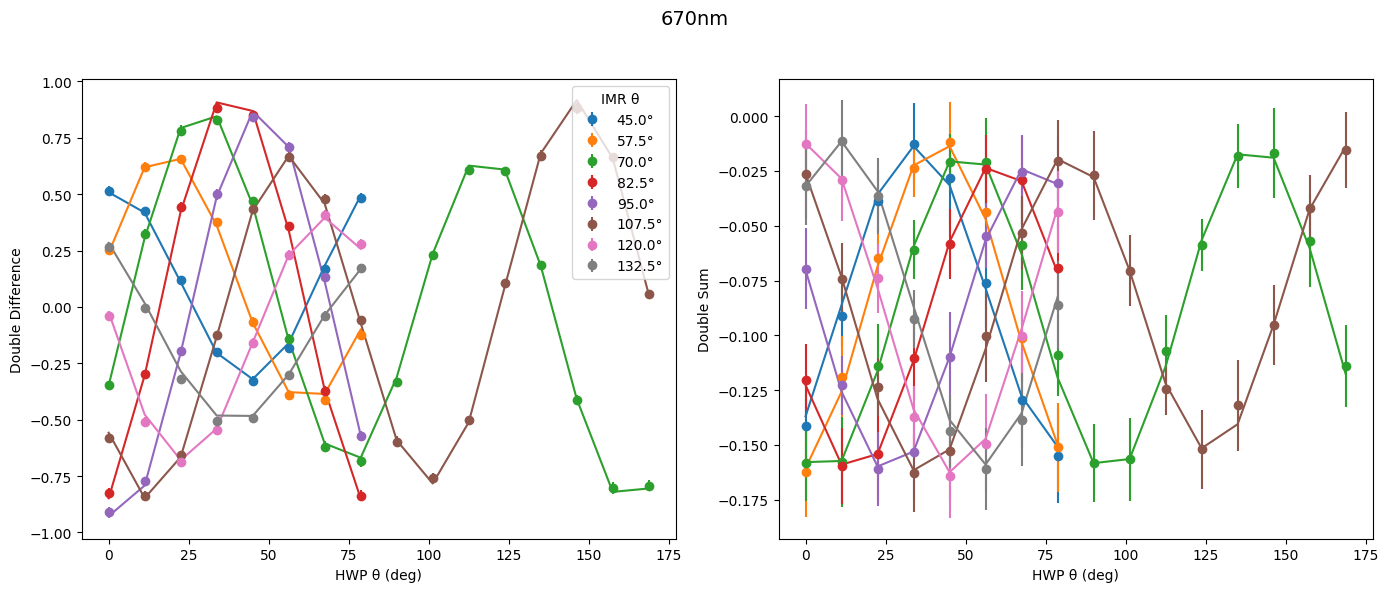

Before p0: {'dichroic': {'phi': -0.015559797190428434, 'epsilon': 0.282939390239206, 'theta': 36.04716048465626}, 'flc': {'phi': 3.0305754584080775, 'delta_theta': 5.0}, 'optics': {'phi': -2.341833948970966, 'epsilon': 0.00320485546404135, 'theta': 4.662478956749448}, 'image_rotator': {'phi': 2.002594611820342}, 'hwp': {'phi': 2.8861079106357455, 'delta_theta': 0.9553170981614993}, 'lp': {'theta': 4.7860818620990155}}
Iteration #: 2
logl_value: 16.431366215516853
Best Fit Parameters: [-2.03773002e-02  2.94894140e-01  3.64175760e+01  3.03856995e+00
  4.99931251e+00 -2.34293194e+00  3.15587368e-03  4.67578192e+00
  2.00184120e+00  2.88737477e+00 -1.43064637e+00 -4.01502369e-02]
After p0: {'dichroic': {'phi': -0.020377300163114627, 'epsilon': 0.2948941398474152, 'theta': 36.41757600676469}, 'flc': {'phi': 3.038569945092393, 'delta_theta': 4.999312505909972}, 'optics': {'phi': -2.342931937507424, 'epsilon': 0.003155873677750995, 'theta': 4.675781920682663}, 'image_rotator': {'phi': 2.00184

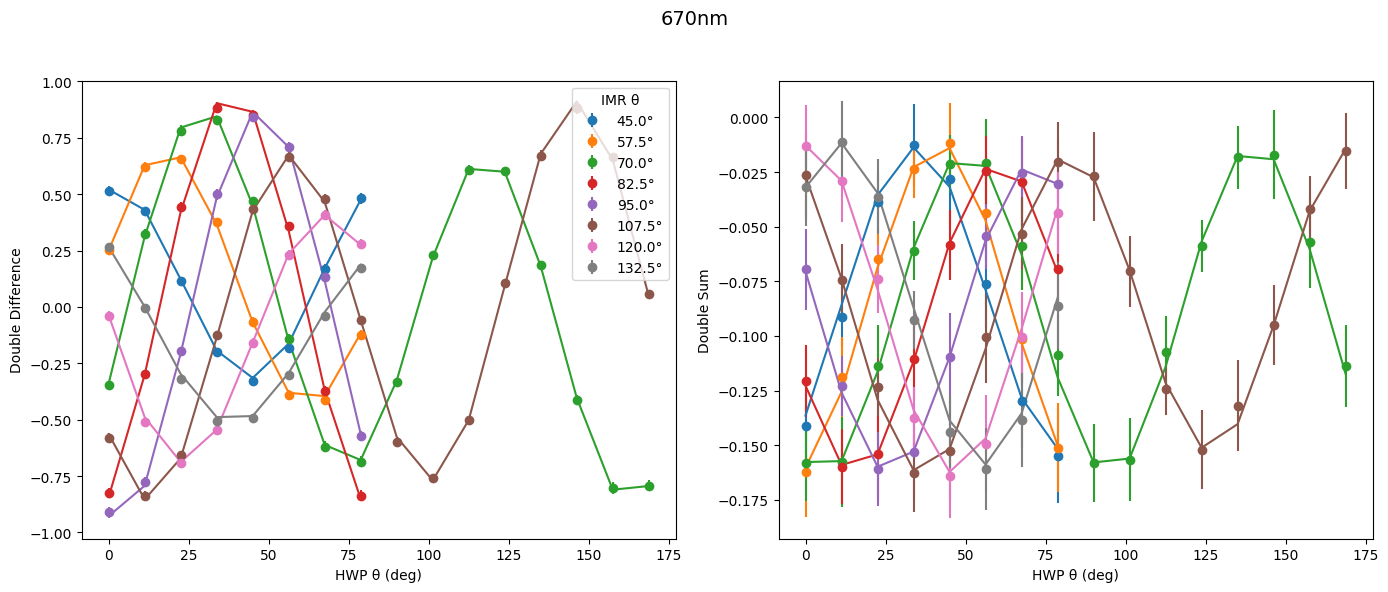

Before p0: {'dichroic': {'phi': -0.020377300163114627, 'epsilon': 0.2948941398474152, 'theta': 36.41757600676469}, 'flc': {'phi': 3.038569945092393, 'delta_theta': 4.999312505909972}, 'optics': {'phi': -2.342931937507424, 'epsilon': 0.003155873677750995, 'theta': 4.675781920682663}, 'image_rotator': {'phi': 2.0018412012222564}, 'hwp': {'phi': 2.887374770537736, 'delta_theta': -1.430646365766347}, 'lp': {'theta': -0.04015023689210094}}
Iteration #: 3
logl_value: 16.424760676970106
Best Fit Parameters: [-1.98613473e-02  2.94436994e-01  3.64041686e+01  3.03759723e+00
  4.99999933e+00 -2.34385426e+00  3.31421422e-03  4.67886479e+00
  2.00158057e+00  2.88731149e+00 -1.46380285e+00 -9.87984777e-02]
After p0: {'dichroic': {'phi': -0.019861347316717397, 'epsilon': 0.29443699381616906, 'theta': 36.40416857508258}, 'flc': {'phi': 3.037597230607444, 'delta_theta': 4.9999993259257565}, 'optics': {'phi': -2.343854261719583, 'epsilon': 0.0033142142190900484, 'theta': 4.678864792752783}, 'image_rotat

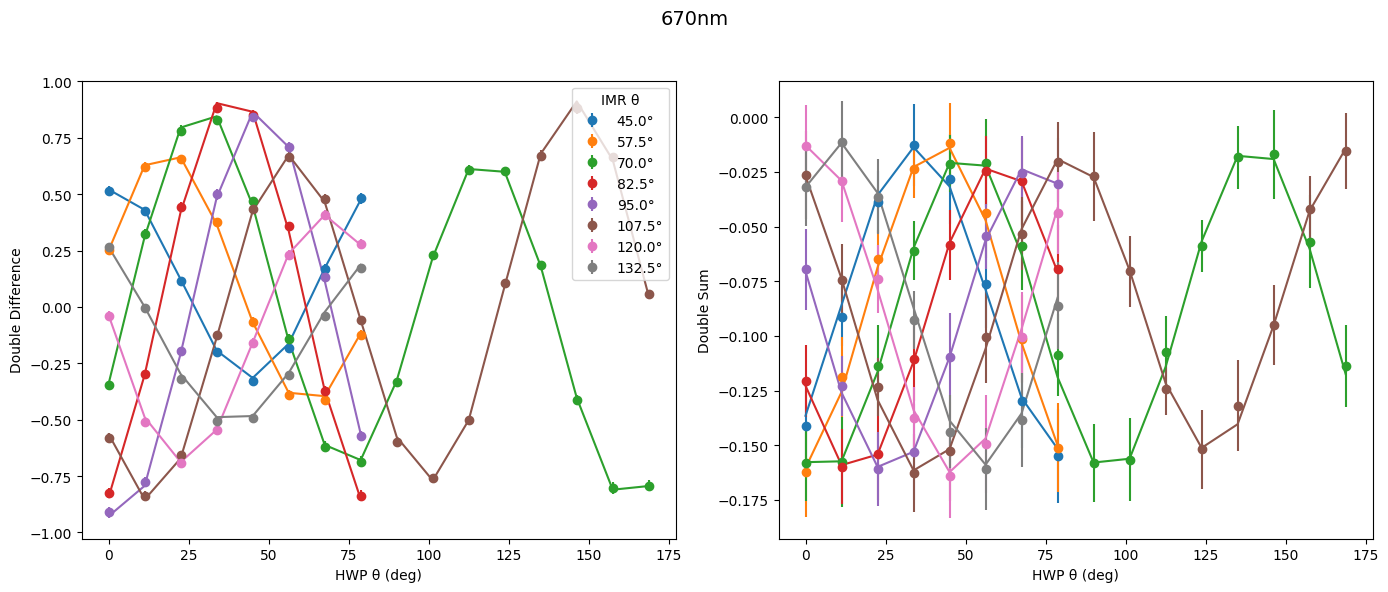

Before p0: {'dichroic': {'phi': -0.019861347316717397, 'epsilon': 0.29443699381616906, 'theta': 36.40416857508258}, 'flc': {'phi': 3.037597230607444, 'delta_theta': 4.9999993259257565}, 'optics': {'phi': -2.343854261719583, 'epsilon': 0.0033142142190900484, 'theta': 4.678864792752783}, 'image_rotator': {'phi': 2.001580570325066}, 'hwp': {'phi': 2.887311489816378, 'delta_theta': -1.4638028471848954}, 'lp': {'theta': -0.09879847769633318}}
Iteration #: 4
logl_value: 16.424755264337776
Best Fit Parameters: [-1.98486203e-02  2.94450015e-01  3.64047201e+01  3.03758480e+00
  4.99999969e+00 -2.34380926e+00  3.31003498e-03  4.67872619e+00
  2.00158115e+00  2.88730478e+00 -1.46391978e+00 -9.86406239e-02]
After p0: {'dichroic': {'phi': -0.019848620254438086, 'epsilon': 0.2944500147916811, 'theta': 36.40472005339994}, 'flc': {'phi': 3.037584797215298, 'delta_theta': 4.999999693602973}, 'optics': {'phi': -2.3438092606250613, 'epsilon': 0.003310034983309295, 'theta': 4.678726190406696}, 'image_rota

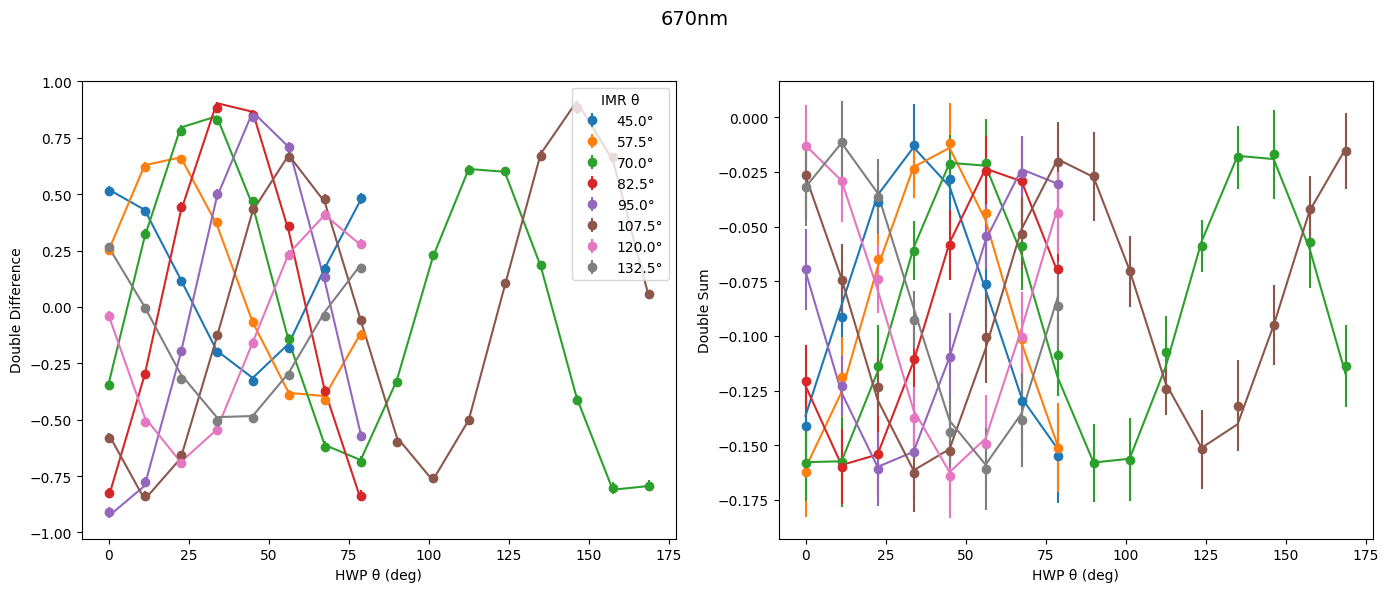

Before p0: {'dichroic': {'phi': -0.019848620254438086, 'epsilon': 0.2944500147916811, 'theta': 36.40472005339994}, 'flc': {'phi': 3.037584797215298, 'delta_theta': 4.999999693602973}, 'optics': {'phi': -2.3438092606250613, 'epsilon': 0.003310034983309295, 'theta': 4.678726190406696}, 'image_rotator': {'phi': 2.001581149808482}, 'hwp': {'phi': 2.887304781846935, 'delta_theta': -1.4639197774797488}, 'lp': {'theta': -0.09864062386105982}}
Iteration #: 5
logl_value: 16.424750641040788
Best Fit Parameters: [-1.98533859e-02  2.94412933e-01  3.64035073e+01  3.03759240e+00
  4.99999993e+00 -2.34379256e+00  3.30886066e-03  4.67873037e+00
  2.00157490e+00  2.88730374e+00 -1.46454751e+00 -9.99477776e-02]
After p0: {'dichroic': {'phi': -0.019853385875164963, 'epsilon': 0.2944129326963574, 'theta': 36.40350734833936}, 'flc': {'phi': 3.037592401677654, 'delta_theta': 4.999999928914658}, 'optics': {'phi': -2.3437925586158226, 'epsilon': 0.0033088606622219486, 'theta': 4.678730365543897}, 'image_rotat

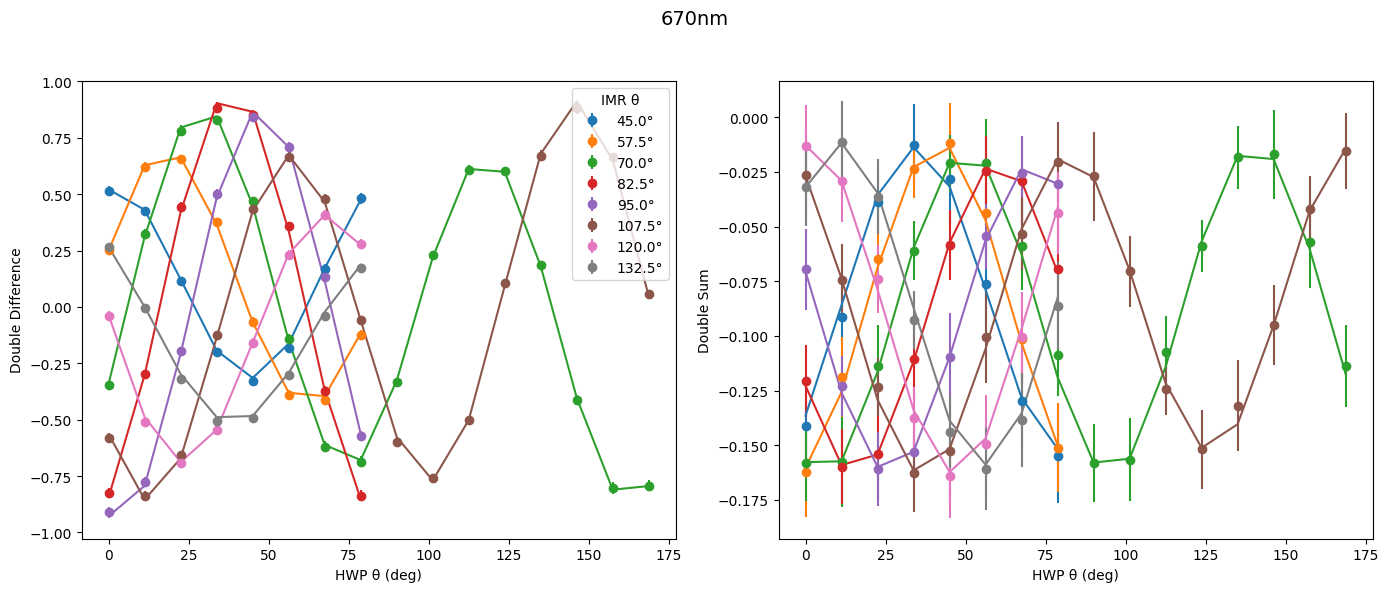

Before p0: {'dichroic': {'phi': -0.019853385875164963, 'epsilon': 0.2944129326963574, 'theta': 36.40350734833936}, 'flc': {'phi': 3.037592401677654, 'delta_theta': 4.999999928914658}, 'optics': {'phi': -2.3437925586158226, 'epsilon': 0.0033088606622219486, 'theta': 4.678730365543897}, 'image_rotator': {'phi': 2.0015749002935985}, 'hwp': {'phi': 2.8873037365217415, 'delta_theta': -1.4645475135185833}, 'lp': {'theta': -0.09994777756040982}}
Iteration #: 6
logl_value: 16.42475040797753
Best Fit Parameters: [-1.98489437e-02  2.94413343e-01  3.64036020e+01  3.03758590e+00
  4.99999996e+00 -2.34379462e+00  3.30818688e-03  4.67874122e+00
  2.00157447e+00  2.88730400e+00 -1.46452839e+00 -9.97968549e-02]
After p0: {'dichroic': {'phi': -0.019848943724534093, 'epsilon': 0.29441334272947817, 'theta': 36.403601975661786}, 'flc': {'phi': 3.0375858960173545, 'delta_theta': 4.999999960610627}, 'optics': {'phi': -2.343794619623271, 'epsilon': 0.003308186884396258, 'theta': 4.678741220274231}, 'image_ro

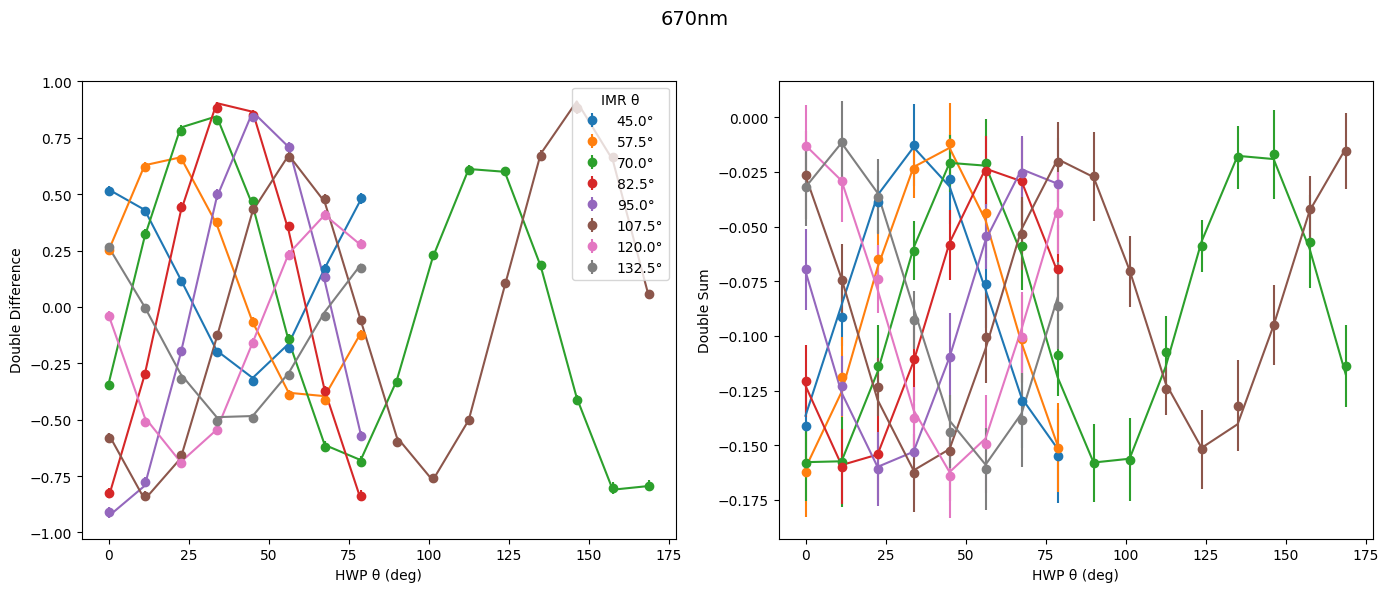

Before p0: {'dichroic': {'phi': -0.019848943724534093, 'epsilon': 0.29441334272947817, 'theta': 36.403601975661786}, 'flc': {'phi': 3.0375858960173545, 'delta_theta': 4.999999960610627}, 'optics': {'phi': -2.343794619623271, 'epsilon': 0.003308186884396258, 'theta': 4.678741220274231}, 'image_rotator': {'phi': 2.001574473585658}, 'hwp': {'phi': 2.887304001128639, 'delta_theta': -1.4645283888823186}, 'lp': {'theta': -0.09979685489146622}}
Iteration #: 7
logl_value: 16.4247502780535
Best Fit Parameters: [-1.98419990e-02  2.94411168e-01  3.64035084e+01  3.03757456e+00
  4.99999998e+00 -2.34381393e+00  3.30873118e-03  4.67873437e+00
  2.00157367e+00  2.88730401e+00 -1.46446661e+00 -9.96323657e-02]
After p0: {'dichroic': {'phi': -0.019841998991489217, 'epsilon': 0.2944111678536384, 'theta': 36.40350835581525}, 'flc': {'phi': 3.037574557358597, 'delta_theta': 4.999999976969078}, 'optics': {'phi': -2.3438139335632218, 'epsilon': 0.0033087311813628432, 'theta': 4.678734366979775}, 'image_rotat

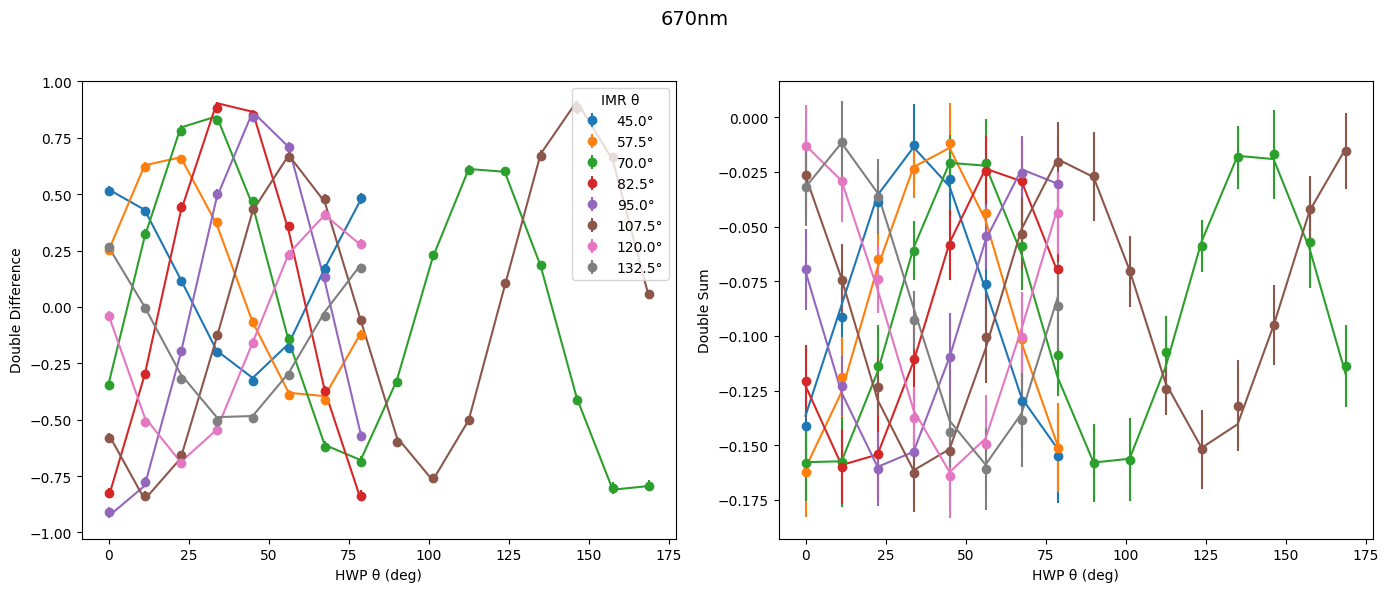

Before p0: {'dichroic': {'phi': -0.019841998991489217, 'epsilon': 0.2944111678536384, 'theta': 36.40350835581525}, 'flc': {'phi': 3.037574557358597, 'delta_theta': 4.999999976969078}, 'optics': {'phi': -2.3438139335632218, 'epsilon': 0.0033087311813628432, 'theta': 4.678734366979775}, 'image_rotator': {'phi': 2.001573665969184}, 'hwp': {'phi': 2.8873040078941576, 'delta_theta': -1.4644666133135582}, 'lp': {'theta': -0.09963236572993839}}
Iteration #: 8
logl_value: 16.424750243123015
Best Fit Parameters: [-1.98388642e-02  2.94413197e-01  3.64035868e+01  3.03757016e+00
  4.99999998e+00 -2.34381754e+00  3.30903399e-03  4.67874681e+00
  2.00157520e+00  2.88730360e+00 -1.46444756e+00 -9.95469384e-02]
After p0: {'dichroic': {'phi': -0.019838864216964902, 'epsilon': 0.29441319662740806, 'theta': 36.403586843360145}, 'flc': {'phi': 3.0375701600720655, 'delta_theta': 4.999999978407333}, 'optics': {'phi': -2.3438175423870966, 'epsilon': 0.0033090339890934615, 'theta': 4.678746808274332}, 'image_

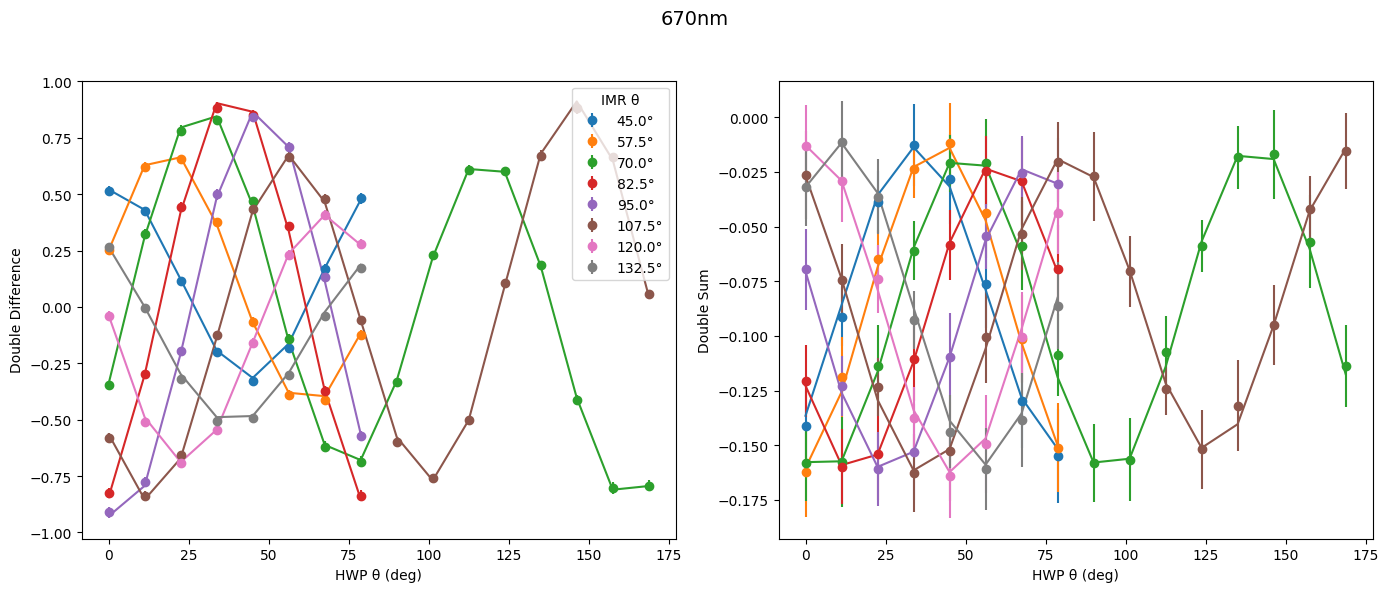

Before p0: {'dichroic': {'phi': -0.019838864216964902, 'epsilon': 0.29441319662740806, 'theta': 36.403586843360145}, 'flc': {'phi': 3.0375701600720655, 'delta_theta': 4.999999978407333}, 'optics': {'phi': -2.3438175423870966, 'epsilon': 0.0033090339890934615, 'theta': 4.678746808274332}, 'image_rotator': {'phi': 2.0015752000027813}, 'hwp': {'phi': 2.8873035952027335, 'delta_theta': -1.4644475627843325}, 'lp': {'theta': -0.0995469383886006}}
Iteration #: 9
logl_value: 16.42475023085017
Best Fit Parameters: [-1.98396164e-02  2.94413186e-01  3.64036090e+01  3.03757152e+00
  4.99999999e+00 -2.34381923e+00  3.30850386e-03  4.67874602e+00
  2.00157460e+00  2.88730299e+00 -1.46445196e+00 -9.95800596e-02]
After p0: {'dichroic': {'phi': -0.019839616412043765, 'epsilon': 0.29441318642128605, 'theta': 36.40360899199804}, 'flc': {'phi': 3.0375715195942954, 'delta_theta': 4.9999999921353675}, 'optics': {'phi': -2.343819231721988, 'epsilon': 0.003308503864908975, 'theta': 4.678746024656297}, 'image_

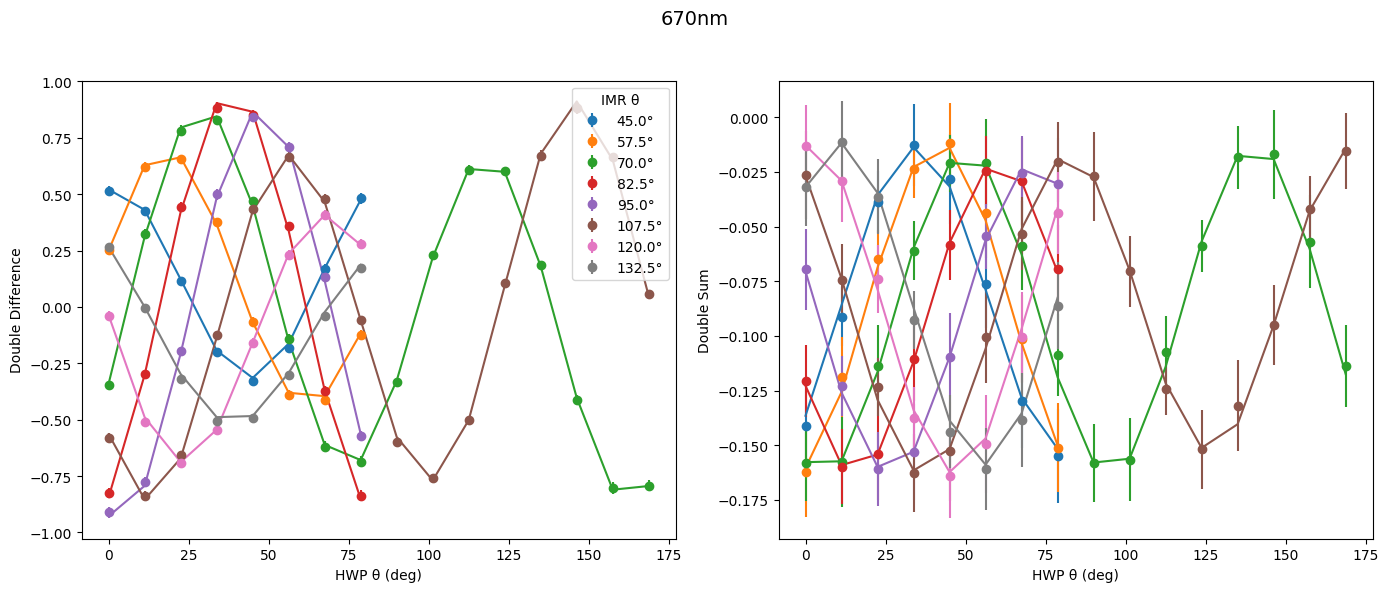

Before p0: {'dichroic': {'phi': -0.019839616412043765, 'epsilon': 0.29441318642128605, 'theta': 36.40360899199804}, 'flc': {'phi': 3.0375715195942954, 'delta_theta': 4.9999999921353675}, 'optics': {'phi': -2.343819231721988, 'epsilon': 0.003308503864908975, 'theta': 4.678746024656297}, 'image_rotator': {'phi': 2.0015746013408675}, 'hwp': {'phi': 2.887302994783675, 'delta_theta': -1.4644519586901033}, 'lp': {'theta': -0.09958005957524464}}
Iteration #: 10
logl_value: 16.424750210204433
Best Fit Parameters: [-1.98411139e-02  2.94413126e-01  3.64035972e+01  3.03757375e+00
  4.99999999e+00 -2.34381488e+00  3.30844664e-03  4.67874139e+00
  2.00157471e+00  2.88730325e+00 -1.46448005e+00 -9.96442225e-02]
After p0: {'dichroic': {'phi': -0.019841113856399063, 'epsilon': 0.2944131256330149, 'theta': 36.403597244165695}, 'flc': {'phi': 3.037573748270654, 'delta_theta': 4.999999992359122}, 'optics': {'phi': -2.343814879908652, 'epsilon': 0.0033084466415758632, 'theta': 4.678741393858601}, 'image_r

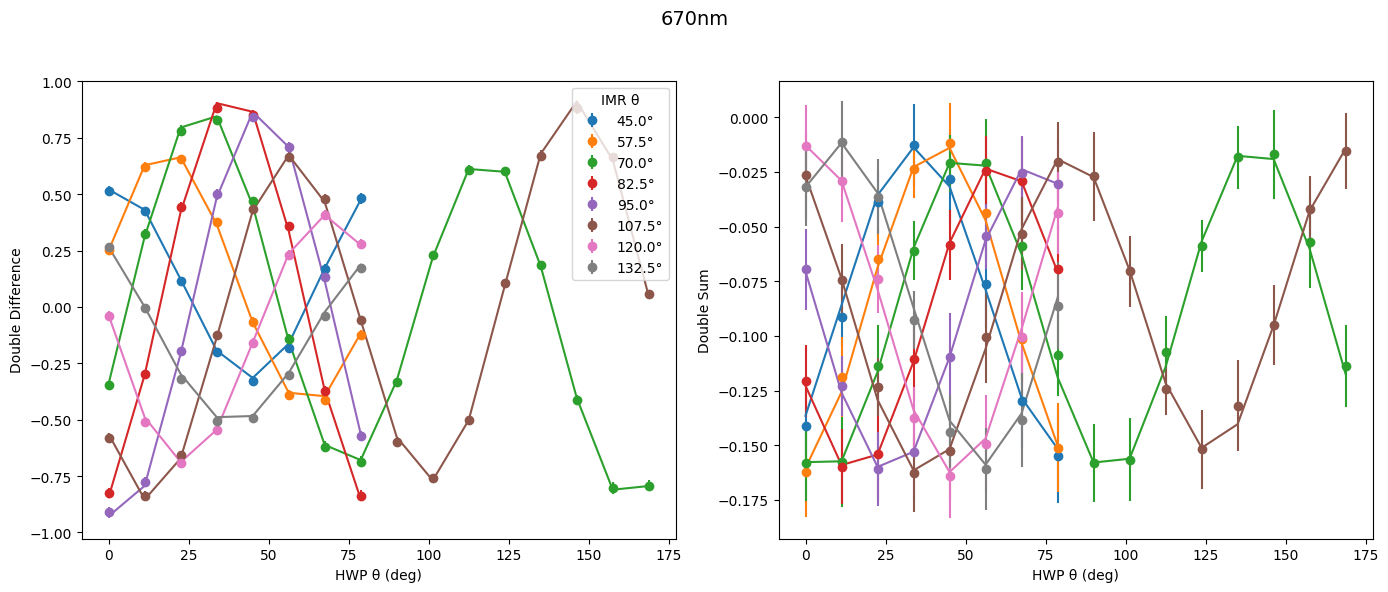

Before p0: {'dichroic': {'phi': -0.019841113856399063, 'epsilon': 0.2944131256330149, 'theta': 36.403597244165695}, 'flc': {'phi': 3.037573748270654, 'delta_theta': 4.999999992359122}, 'optics': {'phi': -2.343814879908652, 'epsilon': 0.0033084466415758632, 'theta': 4.678741393858601}, 'image_rotator': {'phi': 2.001574706119329}, 'hwp': {'phi': 2.887303250858107, 'delta_theta': -1.4644800489125058}, 'lp': {'theta': -0.09964422245983673}}
Iteration #: 11
logl_value: 16.424750210204433
Best Fit Parameters: [-1.98411139e-02  2.94413126e-01  3.64035972e+01  3.03757375e+00
  4.99999999e+00 -2.34381488e+00  3.30844664e-03  4.67874139e+00
  2.00157471e+00  2.88730325e+00 -1.46448005e+00 -9.96442225e-02]
Stopping: logl did not improve over the previous iteration.


In [7]:
# Unpolarized light for s_in as there is LP in the system already
s_in = np.array([1, 0, 0, 0])
bounds_dict = {
    "dichroic": {
        "phi": (-2 * np.pi, 2 * np.pi),
        "epsilon": (0, 1),
        "theta": (-90, 90)
    },
    "flc": {
        "phi": (0.4 * 2 * np.pi, 0.6 * 2 * np.pi),
        "delta_theta": (-5, 5)
    },
    "optics": {
        "phi": (-2 * np.pi, 2 * np.pi),
        "epsilon": (0, 1),
        "theta": (-90, 90)
    },
    "image_rotator": {
        "phi": (delta_derot - abs(delta_derot) * 0.1, delta_derot + abs(delta_derot) * 0.1),
    },
    "hwp": {
        "phi": (delta_HWP - abs(delta_HWP) * 0.1, delta_HWP + abs(delta_HWP) * 0.1),
        "delta_theta": (-5, 5)
    },
    "lp": {
        "theta": (-5, 5)
    }
}

# Now flatten the bounds in the same order as p0_keywords
p0_values, p0_keywords = inst.parse_configuration(p0)
for (comp, param), val in zip(p0_keywords, p0_values):
    lower, upper = bounds_dict[comp][param]
    if not (lower <= val <= upper):
        print(f"{comp}.{param} = {val} is outside bounds {lower} to {upper}")
bounds = [bounds_dict[comp][param] for comp, param in p0_keywords]

# Counters for iterative fitting
iteration = 1
previous_logl_value = np.inf
new_logl_value = None
best_result = None

while True:
    print("Before p0: " + str(p0))
    result, new_logl_value = inst.minimize_system_mueller_matrix(p0, system_mm, 
        interleaved_values, interleaved_stds, configuration_list, s_in = s_in,
        process_dataset = inst.process_dataset, 
        process_errors = inst.process_errors, 
        process_model = inst.process_model, bounds = bounds)
    new_logl_value = float(new_logl_value)
    
    # Print statements
    print("Iteration #: " + str(iteration))
    print("logl_value: " + str(new_logl_value))
    print("Best Fit Parameters: " + str(result.x))

    if new_logl_value >= previous_logl_value:
        print("Stopping: logl did not improve over the previous iteration.")
        if best_result is not None:
            result = best_result
        break

    previous_logl_value = new_logl_value
    best_result = result

    # Updating p0 and saving the latest best fit before plotting.
    inst.update_p0(p0, result.x)
    print("After p0: " + str(p0))

    filename = saved_fit_filename
    with open(filename, 'w') as f:
        json.dump(p0, f, indent=4)
    print("Saved latest best fit to: " + filename)

    # Making a plot
    updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
    model = inst.model(result.x, p0_keywords, updated_system_mm, configuration_list, 
    process_model = inst.process_model)

    inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
        configuration_list, wavelength = wavelength_string)

    iteration += 1


# Step 6: Plot model with best fit

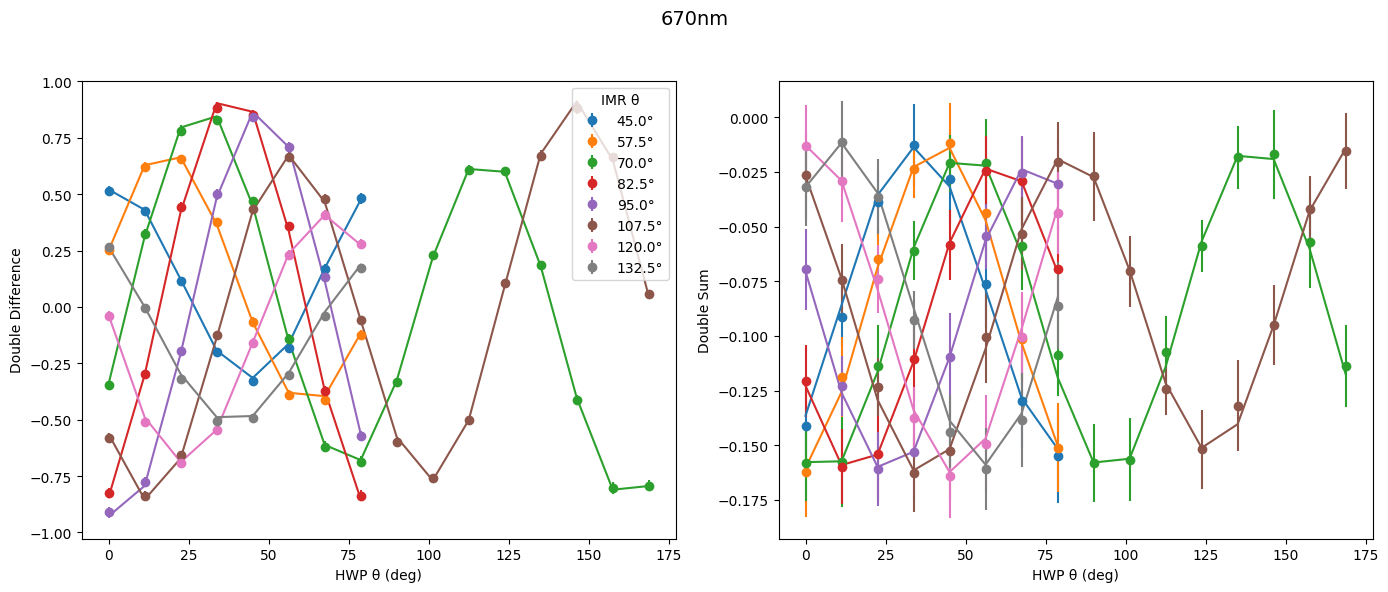

In [8]:
# Generate model with p0 keywords but scipy minimized results
# print(result.x)
# print(p0_keywords)

# Manually adjusting for a good fit
dichroic_phi = 0 # (waves)
dichroic_theta = 0 # (degrees)
# result.x = [2 * np.pi * dichroic_phi, dichroic_theta]

updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
model = inst.model(result.x, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)